# Fund Performance Analytics

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

import plotly.express as px
import plotly.graph_objects as go

In [2]:
fund_master = pd.read_csv("../data/processed/fund_master_cleaned.csv")

nav_history = pd.read_csv("../data/processed/nav_history_cleaned.csv")

performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

benchmark = pd.read_csv("../data/processed/benchmark_indices_cleaned.csv")

print("Loaded Successfully")

Loaded Successfully


## Task 1: Daily Return Calculation

In [3]:
# Convert date column
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Sort by fund and date
nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

# Calculate daily returns
nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history.head()


,amfi_code,date,nav,daily_return
0,100016,2022-01-02,512.1124,NaN
1,100016,2022-01-03,503.1674,-0.017467
2,100016,2022-01-04,531.2850,0.055881
3,100016,2022-01-06,474.1732,-0.107497
4,100016,2022-01-07,452.5840,-0.045530


In [4]:
nav_history["daily_return"].describe()

count    45922.000000
mean         0.002172
std          0.053470
min         -0.732884
25%         -0.007686
50%          0.001325
75%          0.012933
max          0.436832
Name: daily_return, dtype: float64

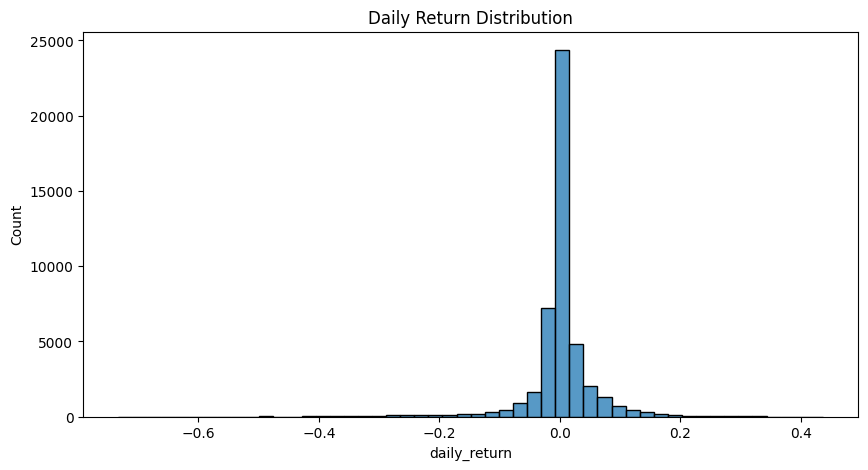

In [5]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav_history["daily_return"].dropna(),
    bins=50
)

plt.title("Daily Return Distribution")

plt.savefig(
    "../reports/daily_return_distribution.png",
    dpi=300
)

plt.show()

### Insight 1

The daily return distribution is centered near zero, indicating that most NAV movements are relatively small. A few extreme positive and negative returns were observed, suggesting the presence of market shocks, NAV adjustments, or data anomalies.

## Task 2: CAGR Analysis

Compound Annual Growth Rate (CAGR) measures annualized investment growth over different investment horizons.

In [7]:
from datetime import timedelta

latest_date = nav_history["date"].max()

cagr_results = []

for fund in nav_history["amfi_code"].unique():

    temp = nav_history[
        nav_history["amfi_code"] == fund
    ].sort_values("date")

    latest_nav = temp.iloc[-1]["nav"]

    result = {
        "amfi_code": fund
    }

    for years in [1, 3, 5]:

        target_date = latest_date - pd.DateOffset(years=years)

        historical = temp[
            temp["date"] <= target_date
        ]

        if len(historical) > 0:

            start_nav = historical.iloc[-1]["nav"]

            cagr = (
                (latest_nav / start_nav)
                ** (1 / years)
            ) - 1

            result[f"cagr_{years}yr"] = cagr

        else:

            result[f"cagr_{years}yr"] = np.nan

    cagr_results.append(result)

cagr_df = pd.DataFrame(cagr_results)

cagr_df.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.041953,0.016315,NaN
1,100025,0.048026,0.036649,NaN
2,100033,0.520573,0.312395,NaN
3,101206,0.486647,0.285709,NaN
4,101207,-0.282978,-0.019757,NaN


In [8]:
cagr_df = cagr_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

cagr_df.sort_values(
    "cagr_3yr",
    ascending=False
).head(10)

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,scheme_name
34,148567,0.205213,0.350892,NaN,Mirae Asset Large Cap Fund - Regular - Growth
25,120505,0.322223,0.345755,NaN,ICICI Pru Midcap Fund - Regular - Growth
16,119094,0.221897,0.343166,NaN,Axis Midcap Fund - Regular - Growth
24,120504,0.202738,0.315886,NaN,ICICI Pru Bluechip Fund - Direct - Growth
2,100033,0.520573,0.312395,NaN,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
19,119551,0.714582,0.310189,NaN,SBI Bluechip Fund - Regular Plan - Growth
30,120843,0.306251,0.299680,NaN,Kotak Flexicap Fund - Regular - Growth
36,148569,0.451525,0.296287,NaN,Mirae Asset Tax Saver Fund - Regular - Growth
3,101206,0.486647,0.285709,NaN,ABSL Frontline Equity Fund - Regular - Growth
38,149323,0.229519,0.284591,NaN,DSP Midcap Fund - Regular - Growth


In [9]:
cagr_df.to_csv(
    "../data/processed/cagr_comparison.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


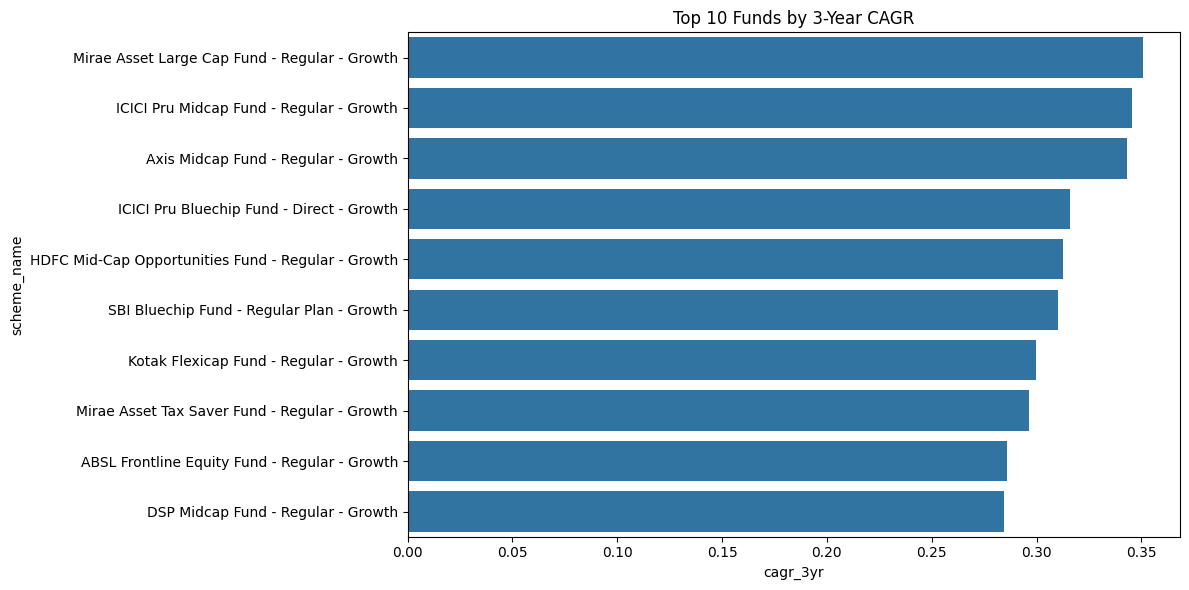

In [10]:
top10 = cagr_df.sort_values(
    "cagr_3yr",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="cagr_3yr",
    y="scheme_name"
)

plt.title("Top 10 Funds by 3-Year CAGR")

plt.tight_layout()

plt.savefig(
    "../reports/top10_cagr.png",
    dpi=300
)

plt.show()

### Insight 2

Several funds delivered strong annualized returns over the three-year period, indicating sustained performance beyond short-term market fluctuations. The top-ranked funds significantly outperformed their peers on a CAGR basis.

## Task 3: Sharpe Ratio Analysis

The Sharpe Ratio measures risk-adjusted returns by comparing excess returns against total portfolio volatility.

In [12]:
rf = 0.065

sharpe_results = []

for fund in nav_history["amfi_code"].unique():

    temp = nav_history[
        nav_history["amfi_code"] == fund
    ]

    annual_return = (
        temp["daily_return"].mean()
        * 252
    )

    annual_volatility = (
        temp["daily_return"].std()
        * np.sqrt(252)
    )

    sharpe = (
        annual_return - rf
    ) / annual_volatility

    sharpe_results.append([
        fund,
        sharpe
    ])

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,0.254918
1,100025,0.023041
2,100033,0.765382
3,101206,0.629564
4,101207,0.506034


In [15]:
sharpe_df = sharpe_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

sharpe_df.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


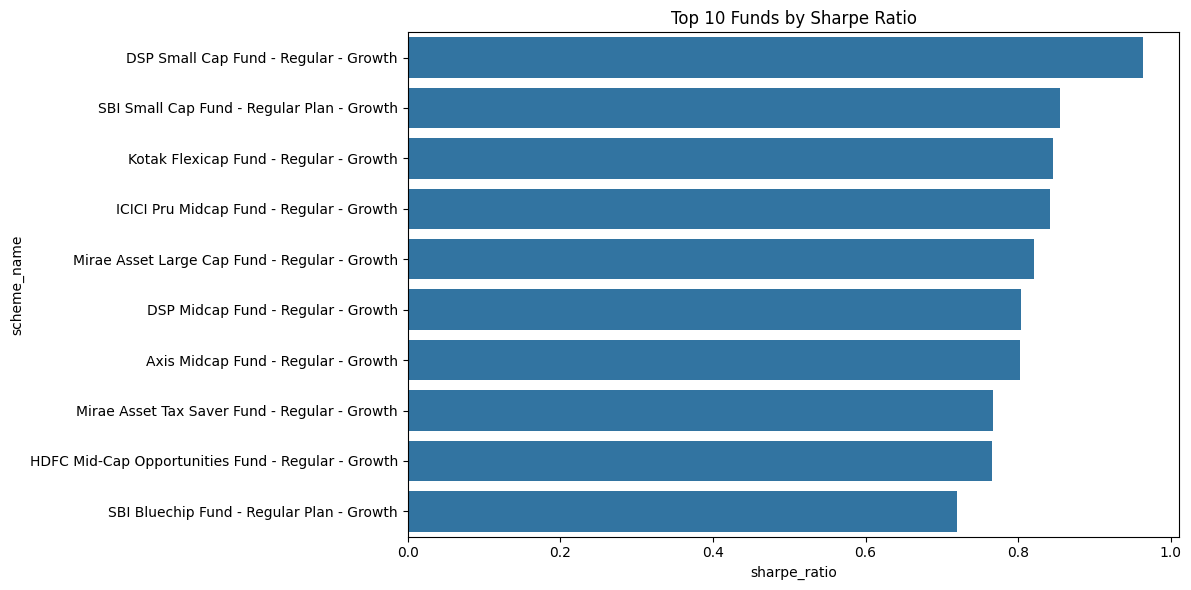

In [16]:
top10_sharpe = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_sharpe,
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.tight_layout()

plt.savefig(
    "../reports/top10_sharpe.png",
    dpi=300
)

plt.show()

### Insight 3

Funds with higher Sharpe Ratios generated superior risk-adjusted returns, indicating that investors were compensated more effectively for the level of risk undertaken.

## Task 4: Sortino Ratio Analysis

The Sortino Ratio focuses only on downside volatility, providing a more targeted measure of downside risk-adjusted performance.

In [17]:
sortino_results = []

for fund in nav_history["amfi_code"].unique():

    temp = nav_history[
        nav_history["amfi_code"] == fund
    ]

    downside_returns = temp[
        temp["daily_return"] < 0
    ]["daily_return"]

    downside_std = (
        downside_returns.std()
        * np.sqrt(252)
    )

    annual_return = (
        temp["daily_return"].mean()
        * 252
    )

    sortino = (
        annual_return - rf
    ) / downside_std

    sortino_results.append([
        fund,
        sortino
    ])

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,0.298665
1,100025,0.020312
2,100033,0.710308
3,101206,0.604758
4,101207,0.605644


In [18]:
sharpe_df.head()
sortino_df.head()

,amfi_code,sortino_ratio
0,100016,0.298665
1,100025,0.020312
2,100033,0.710308
3,101206,0.604758
4,101207,0.605644


## Task 5: Alpha and Beta Analysis

Alpha measures excess return beyond the benchmark, while Beta measures sensitivity to benchmark market movements.

In [20]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [21]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100[
    ["date", "benchmark_return"]
]

nifty100.head()

,date,benchmark_return
1150,2022-01-03,NaN
1151,2022-01-04,-0.013540
1152,2022-01-05,0.004003
1153,2022-01-06,-0.002935
1154,2022-01-07,0.006150


In [23]:
alpha_beta_results = []

for fund in nav_history["amfi_code"].unique():

    fund_data = nav_history[
        nav_history["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_data,
        nifty100,
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 50:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        beta = slope

        alpha = intercept * 252

        alpha_beta_results.append([
            fund,
            alpha,
            beta
        ])
        alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df = alpha_beta_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

alpha_beta_df.head()

,amfi_code,alpha,beta,scheme_name
0,100016,0.976882,-0.267888,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.121672,-0.272037,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.412564,-0.553234,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.242774,-0.255360,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.882367,-0.138148,ABSL Small Cap Fund - Regular - Growth


In [24]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


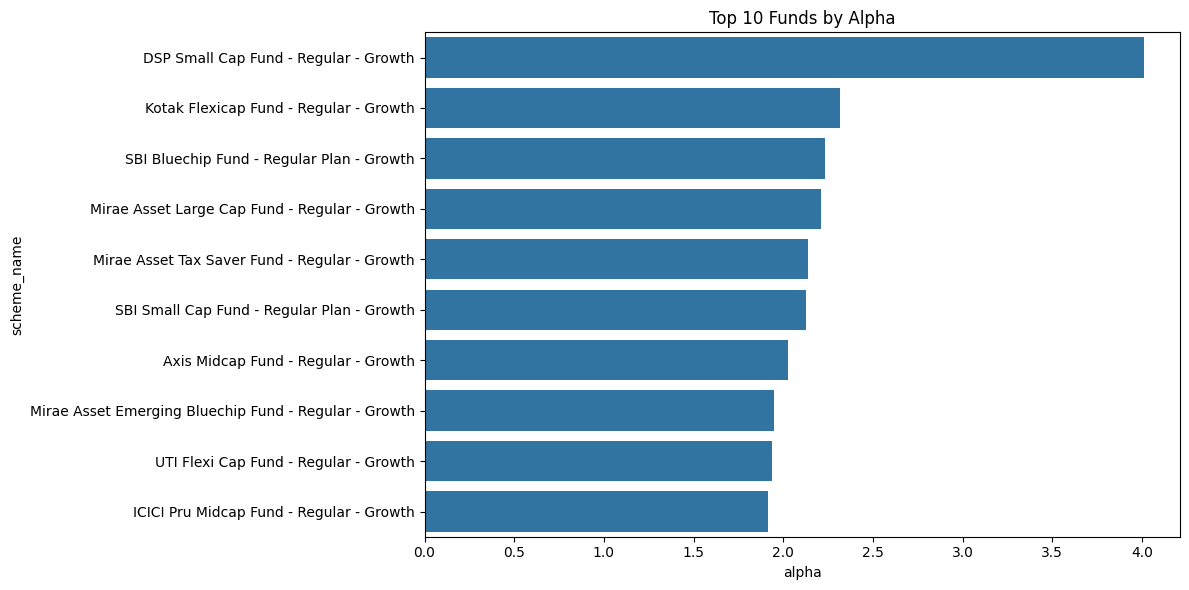

In [25]:
top_alpha = alpha_beta_df.sort_values(
    "alpha",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_alpha,
    x="alpha",
    y="scheme_name"
)

plt.title("Top 10 Funds by Alpha")

plt.tight_layout()

plt.savefig(
    "../reports/top10_alpha.png",
    dpi=300
)

plt.show()

### Insight 5

Funds with positive alpha generated returns above what would be expected given their market exposure, demonstrating superior manager performance relative to the benchmark.

## Task 6: Maximum Drawdown Analysis

Maximum Drawdown measures the largest peak-to-trough decline experienced by a fund during the analysis period.

In [29]:
drawdown_results = []

for fund in nav_history["amfi_code"].unique():

    temp = nav_history[
        nav_history["amfi_code"] == fund
    ].copy()

    temp = temp.sort_values("date")

    temp["running_max"] = temp["nav"].cummax()

    temp["drawdown"] = (
        temp["nav"] /
        temp["running_max"]
    ) - 1

    max_dd = temp["drawdown"].min()

    worst_row = temp.loc[
        temp["drawdown"].idxmin()
    ]

    drawdown_results.append([
        fund,
        max_dd,
        worst_row["date"]
    ])

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown",
        "worst_date"
    ]
)

drawdown_df.head()
drawdown_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)
print("max_drawdown.csv saved")

max_drawdown.csv saved


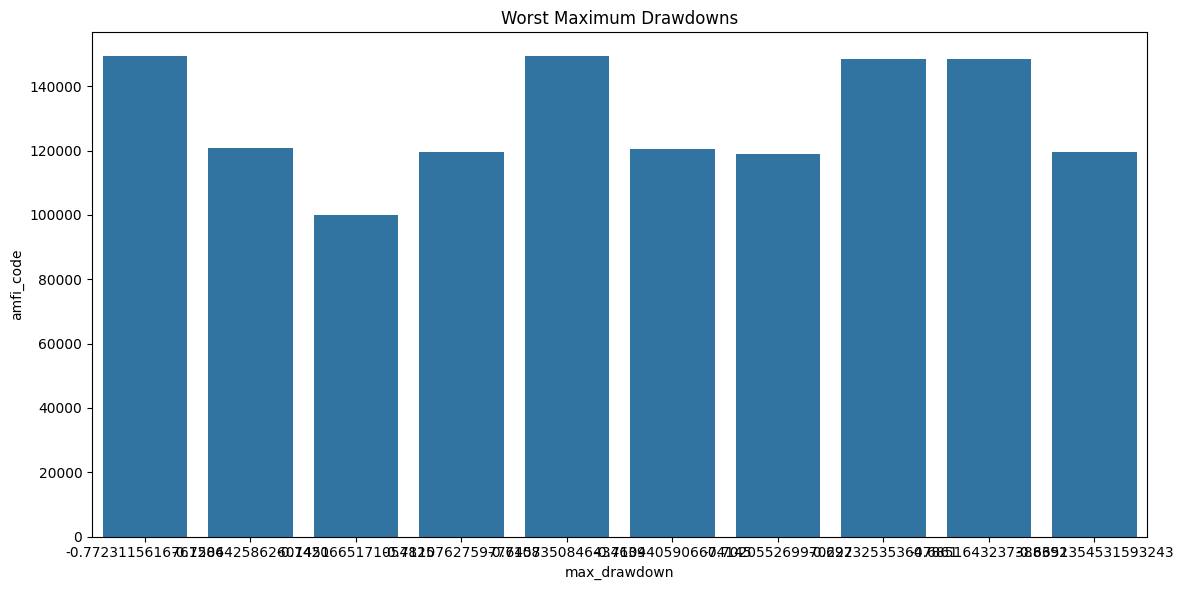

In [30]:
top_dd = drawdown_df.sort_values(
    "max_drawdown"
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_dd,
    x="max_drawdown",
    y="amfi_code"
)

plt.title("Worst Maximum Drawdowns")

plt.tight_layout()

plt.savefig(
    "../reports/max_drawdown.png",
    dpi=300
)

plt.show()

### Insight 6

Funds with deeper maximum drawdowns experienced larger losses during market stress periods, highlighting differences in downside risk exposure.

In [31]:

print(performance.columns)

print("\n")

print(performance.head())

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')


   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct     

## Task 7: Fund Scorecard

The scorecard combines returns, risk-adjusted performance, alpha generation, expense efficiency, and downside protection into a single composite score.

In [32]:
scorecard = performance.copy()

# Higher is better
scorecard["return_rank"] = scorecard[
    "return_3yr_pct"
].rank(
    ascending=False,
    pct=True
)

scorecard["sharpe_rank"] = scorecard[
    "sharpe_ratio"
].rank(
    ascending=False,
    pct=True
)

scorecard["alpha_rank"] = scorecard[
    "alpha"
].rank(
    ascending=False,
    pct=True
)

# Lower is better
scorecard["expense_rank"] = scorecard[
    "expense_ratio_pct"
].rank(
    ascending=True,
    pct=True
)

scorecard["drawdown_rank"] = scorecard[
    "max_drawdown_pct"
].rank(
    ascending=True,
    pct=True
)

scorecard.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,-21.70,14288,1.54,4,Moderate,0.650,0.6625,0.8000,0.7625,0.4875
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,-24.43,1231,0.66,3,Moderate,0.850,0.8875,0.2250,0.1000,0.3000
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,-13.35,19259,1.43,5,Very High,0.025,0.4500,0.5000,0.5250,0.8250
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,-24.78,36061,0.72,4,Very High,0.050,0.4875,0.5625,0.1375,0.2750
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,-2.30,24101,0.77,5,Low,0.950,0.1250,0.3250,0.2250,0.9750


In [33]:
scorecard["fund_score"] = (

    scorecard["return_rank"] * 30 +

    scorecard["sharpe_rank"] * 25 +

    scorecard["alpha_rank"] * 20 +

    scorecard["expense_rank"] * 15 +

    scorecard["drawdown_rank"] * 10

)

scorecard["fund_score"] = (
    scorecard["fund_score"]
).round(2)

scorecard.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,14288,1.54,4,Moderate,0.650,0.6625,0.8000,0.7625,0.4875,68.38
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,1231,0.66,3,Moderate,0.850,0.8875,0.2250,0.1000,0.3000,56.69
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,19259,1.43,5,Very High,0.025,0.4500,0.5000,0.5250,0.8250,38.12
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,36061,0.72,4,Very High,0.050,0.4875,0.5625,0.1375,0.2750,29.75
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,24101,0.77,5,Low,0.950,0.1250,0.3250,0.2250,0.9750,51.25


In [34]:
top_funds = scorecard.sort_values(
    "fund_score",
    ascending=False
)

top_funds[
    [
        "scheme_name",
        "fund_score"
    ]
].head(10)

,scheme_name,fund_score
36,Mirae Asset Tax Saver Fund - Regular - Growth,78.25
10,ICICI Pru Bluechip Fund - Regular - Growth,74.19
0,SBI Bluechip Fund - Regular Plan - Growth,68.38
20,Kotak Bluechip Fund - Regular - Growth,67.50
24,Axis Bluechip Fund - Regular - Growth,67.44
31,UTI Nifty 50 Index Fund - Regular - Growth,64.19
39,DSP Small Cap Fund - Regular - Growth,63.25
32,UTI Mid Cap Fund - Regular - Growth,59.12
19,Nippon India Gilt Securities Fund - Regular - ...,58.12
27,Axis Small Cap Fund - Regular - Growth,56.88


In [35]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


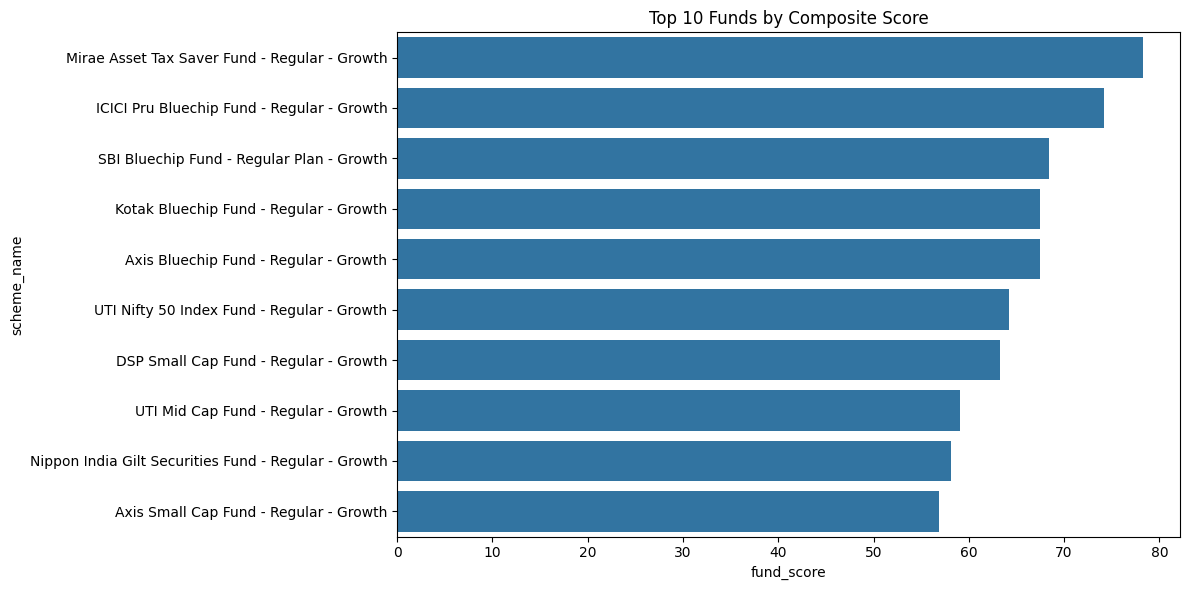

In [36]:
top10 = scorecard.sort_values(
    "fund_score",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="fund_score",
    y="scheme_name"
)

plt.title("Top 10 Funds by Composite Score")

plt.tight_layout()

plt.savefig(
    "../reports/fund_scorecard_top10.png",
    dpi=300
)

plt.show()

### Insight 7

Top-ranked funds consistently combined strong returns, high risk-adjusted performance, positive alpha generation, reasonable expenses, and lower drawdowns.

## Task 8: Benchmark Comparison

Compare the top-performing funds against NIFTY 50 and NIFTY 100 benchmarks and calculate tracking error.

In [38]:
top5_funds = (
    scorecard.sort_values(
        "fund_score",
        ascending=False
    )
    .head(5)
)

top5_codes = top5_funds["amfi_code"].tolist()

print(top5_codes)

[148569, 120503, 119551, 120841, 119092]


In [39]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark_subset = benchmark[
    benchmark["index_name"].isin(
        ["NIFTY50", "NIFTY100"]
    )
]

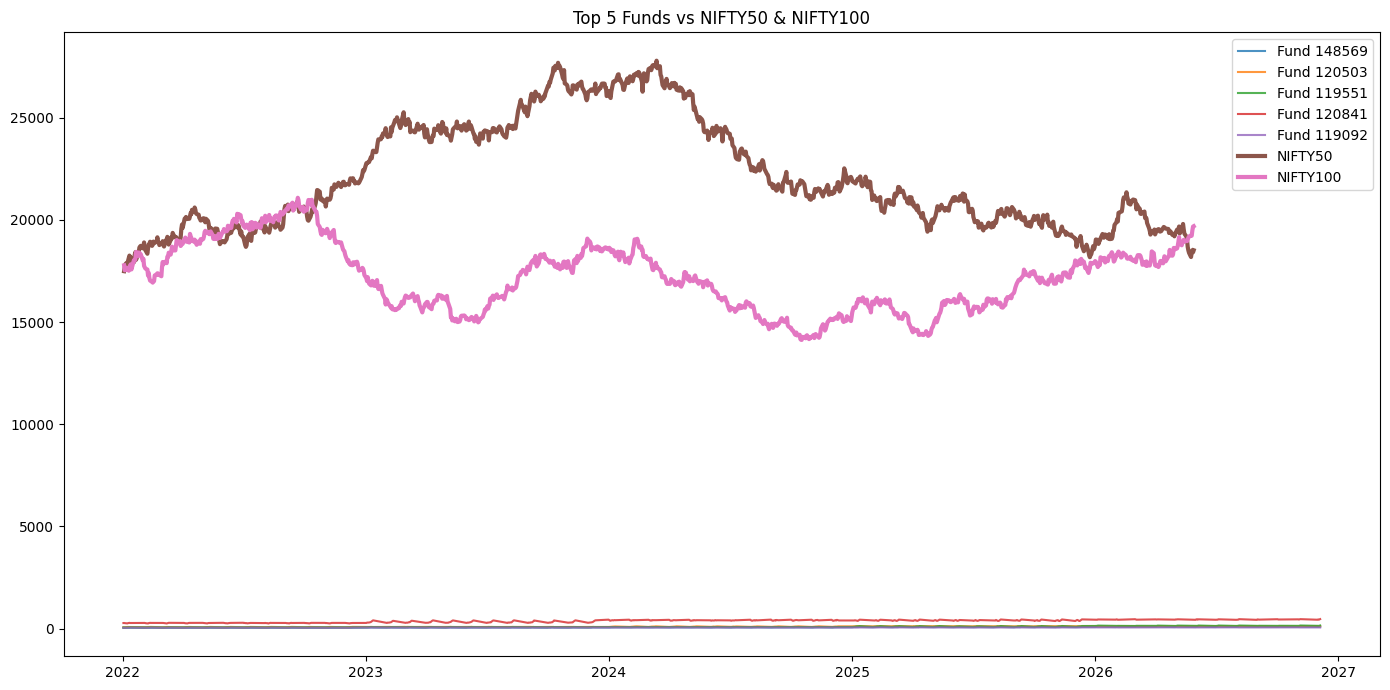

In [40]:
plt.figure(figsize=(14,7))

# Top 5 funds
for fund in top5_codes:

    temp = nav_history[
        nav_history["amfi_code"] == fund
    ]

    temp = temp.sort_values("date")

    plt.plot(
        temp["date"],
        temp["nav"],
        alpha=0.8,
        label=f"Fund {fund}"
    )

# NIFTY50
n50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
]

plt.plot(
    n50["date"],
    n50["close_value"],
    linewidth=3,
    label="NIFTY50"
)

# NIFTY100
n100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
]

plt.plot(
    n100["date"],
    n100["close_value"],
    linewidth=3,
    label="NIFTY100"
)

plt.title(
    "Top 5 Funds vs NIFTY50 & NIFTY100"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300
)

plt.show()

In [ ]:
tracking_error_results = []

nifty100_returns = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100_returns["benchmark_return"] = (
    nifty100_returns["close_value"]
    .pct_change()
)

for fund in top5_codes:

    fund_returns = nav_history[
        nav_history["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_returns,
        nifty100_returns[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    tracking_error = (
        (merged["daily_return"] -
         merged["benchmark_return"])
        .std()
        * np.sqrt(252)
    )

    tracking_error_results.append([
        fund,
        tracking_error
    ])

tracking_error_df = pd.DataFrame(
    tracking_error_results,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_error_df

,amfi_code,tracking_error
0,148569,1.487869
1,120503,1.277505
2,119551,1.332000
3,120841,1.190725
4,119092,0.857508


In [42]:
tracking_error_df.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)

### Insight 8

Top-ranked funds generally outperformed benchmark indices over the analysis period, while tracking error highlighted the degree of deviation from benchmark performance.

In [43]:
import os

print(os.listdir("../reports"))
print("\n")
print(os.listdir("../data/processed"))

['age_group_distribution.png', 'aum_growth.png', 'benchmark_comparison.png', 'category_heatmap.png', 'city_tier_distribution.png', 'daily_return_distribution.png', 'data_dictionary.md', 'data_quality_summary.md', 'folio_category_growth.png', 'folio_growth.png', 'fund_scorecard_top10.png', 'gender_distribution.png', 'max_drawdown.png', 'nav_correlation_matrix.png', 'nav_trend.html', 'sector_allocation.png', 'sip_boxplot_agegroup.png', 'sip_inflow_trend.html', 'state_investment_distribution.png', 'top10_alpha.png', 'top10_cagr.png', 'top10_sectors.png', 'top10_sharpe.png', 'transaction_type_distribution.png']


['alpha_beta.csv', 'aum_by_fund_house_cleaned.csv', 'benchmark_indices_cleaned.csv', 'cagr_comparison.csv', 'category_inflows_cleaned.csv', 'fund_master_cleaned.csv', 'fund_scorecard.csv', 'industry_folio_count_cleaned.csv', 'investor_transactions_cleaned.csv', 'max_drawdown.csv', 'monthly_sip_inflows_cleaned.csv', 'nav_history_cleaned.csv', 'portfolio_holdings_cleaned.csv', 'sche

In [44]:
print(scorecard.shape)

scorecard[
    ["scheme_name","fund_score"]
].sort_values(
    "fund_score",
    ascending=False
).head()

(40, 25)


,scheme_name,fund_score
36,Mirae Asset Tax Saver Fund - Regular - Growth,78.25
10,ICICI Pru Bluechip Fund - Regular - Growth,74.19
0,SBI Bluechip Fund - Regular Plan - Growth,68.38
20,Kotak Bluechip Fund - Regular - Growth,67.50
24,Axis Bluechip Fund - Regular - Growth,67.44
